# 03-2. XGBoost モデル設計 — 2026-03-08

## リクルート飲食店来客数予測コンペティション

**目的**: 02で確定した特徴量セット（48特徴量）を使い、XGBoostモデルを構築し、LightGBMと比較する。

### 本ノートブックの構成
1. データ読み込み（中間データから）
2. モデル概要と選定理由
3. ハイパーパラメータ設定
4. 時系列バリデーションによる学習
5. 予測結果の分析
6. 特徴量重要度の分析
7. LightGBMとの比較
8. ハイパーパラメータチューニング（Optuna）
9. まとめと次ステップ

---
## 1. データ読み込み（中間データから）

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
plt.rcParams['figure.facecolor'] = 'white'

SEED = 42
np.random.seed(SEED)
INTERMEDIATE_DIR = Path('./intermediate')

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# 02の中間データ読み込み
with open(INTERMEDIATE_DIR / '02_feature_design.pkl', 'rb') as f:
    prev_02 = pickle.load(f)

train_df = prev_02['train_features']
valid_df = prev_02['valid_features']
all_features = prev_02['feature_columns']['all_features']
VALID_START = prev_02['VALID_START']

# confirmed_settings の読み込み
confirmed = prev_02['confirmed_settings']
TRAIN_START = confirmed['best_train_start']

# val_folds の読み込み（01 EDAで設計した時系列CV）
val_folds = prev_02['val_folds']

# TRAIN_START フィルタの適用
if TRAIN_START is not None:
    before_len = len(train_df)
    train_df = train_df[train_df['visit_date'] >= TRAIN_START].reset_index(drop=True)
    print(f'TRAIN_START フィルタ適用: {before_len} → {len(train_df)} 行')

# 03-1の結果読み込み（比較用）
with open(INTERMEDIATE_DIR / '03-1_lgbm_results.pkl', 'rb') as f:
    prev_lgbm = pickle.load(f)

print('中間データ読み込み完了')
print(f'  学習データ: {train_df.shape}')
print(f'  検証データ: {valid_df.shape}')
print(f'  特徴量数: {len(all_features)}')

print(f'\n=== 確定設定 (confirmed_settings) ===')
print(f'  学習期間: {confirmed["best_train_period"]} (start={TRAIN_START})')
print(f'  NaN戦略: {confirmed["best_nan_strategy"]}')
print(f'  Rolling設定: {confirmed["best_rolling_config"]}')

print(f'\n=== CV戦略: {len(val_folds)}フォールド時系列CV（01 EDA設計） ===')
for i, fold in enumerate(val_folds):
    print(f'  Fold {i+1}: val_start={fold["val_start"]}, val_end={fold["val_end"]}')

print(f'\nLightGBM参考スコア: RMSLE = {prev_lgbm["score_single"]:.5f}')

---
## 2. モデル概要と選定理由

### XGBoostの特徴とLightGBMとの違い

| 項目 | XGBoost | LightGBM |
|------|---------|----------|
| 木の成長方式 | Level-wise（均等に深くなる） | Leaf-wise（誤差の大きい葉を優先） |
| 分割探索 | Exact / Histogram | Histogram（高速） |
| 正則化 | L1 + L2 + γ（木の複雑さ） | L1 + L2 |
| 欠損値処理 | 自動（最適方向を学習） | 自動 |

### 選定理由
- LightGBMと異なるアルゴリズムで**アンサンブルの多様性**を確保
- Level-wise成長により、過学習しにくい傾向がある
- γパラメータによる木の複雑さの明示的な制御が可能

---
## 3. ハイパーパラメータ設定

| パラメータ | 値 | 根拠 |
|-----------|-----|------|
| `max_depth` | 8 | Level-wiseのため深さで制御（LightGBMのnum_leaves=63相当） |
| `learning_rate` | 0.02 | LightGBMと同条件で比較 |
| `n_estimators` | 2000 | early_stoppingで自動決定 |
| `subsample` | 0.8 | LightGBMと同条件 |
| `colsample_bytree` | 0.8 | LightGBMと同条件 |
| `min_child_weight` | 5 | 過学習抑制 |
| `gamma` | 0.1 | 木の分割に必要な最小損失減少量 |
| `reg_alpha` | 0.1 | L1正則化 |
| `reg_lambda` | 1.0 | L2正則化（XGBoostのデフォルト） |

In [2]:
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'booster': 'gbtree',
    'max_depth': 8,
    'learning_rate': 0.02,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': SEED,
    'n_jobs': -1,
    'verbosity': 0,
}

print('=== XGBoost ハイパーパラメータ ===')
for k, v in xgb_params.items():
    print(f'  {k}: {v}')

=== XGBoost ハイパーパラメータ ===
  objective: reg:squarederror
  eval_metric: rmse
  booster: gbtree
  max_depth: 8
  learning_rate: 0.02
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 5
  gamma: 0.1
  reg_alpha: 0.1
  reg_lambda: 1.0
  random_state: 42
  n_jobs: -1
  verbosity: 0


---
## 4. 時系列バリデーションによる学習

In [3]:
# === Single Split での学習 ===
X_train = train_df[all_features]
y_train = np.log1p(train_df['visitors'])
X_valid = valid_df[all_features]
y_valid = np.log1p(valid_df['visitors'])

dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)

model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=2000,
    evals=[(dtrain, 'train'), (dvalid, 'valid')],
    early_stopping_rounds=100,
    verbose_eval=200,
)

pred_log = model.predict(dvalid)
pred = np.expm1(pred_log)
score_single = rmsle(valid_df['visitors'], pred)

print(f'\n=== Single Split 結果 ===')
print(f'  Best iteration: {model.best_iteration}')
print(f'  XGBoost RMSLE: {score_single:.5f}')
print(f'  LightGBM RMSLE: {prev_lgbm["score_single"]:.5f}')
print(f'  差分: {prev_lgbm["score_single"] - score_single:+.5f}')

[0]	train-rmse:0.79443	valid-rmse:0.82434
[200]	train-rmse:0.47474	valid-rmse:0.50790
[400]	train-rmse:0.45829	valid-rmse:0.50474
[600]	train-rmse:0.44671	valid-rmse:0.50461
[795]	train-rmse:0.43670	valid-rmse:0.50468

=== Single Split 結果 ===
  Best iteration: 695
  XGBoost RMSLE: 0.50468
  LightGBM RMSLE: 0.51615
  差分: +0.01148


In [ ]:
# === 時系列 Cross-Validation（01 EDAで設計した val_folds） ===
# ※ TimeSeriesSplit ではなく、02で検証済みのval_foldsを使用（スコア比較可能性を担保）
full_df = pd.concat([train_df, valid_df], ignore_index=True).sort_values('visit_date').reset_index(drop=True)

cv_scores = []

for i, fold in enumerate(val_folds, 1):
    val_start = pd.Timestamp(fold['val_start'])
    val_end = pd.Timestamp(fold['val_end'])
    
    train_mask = full_df['visit_date'] < val_start
    valid_mask = (full_df['visit_date'] >= val_start) & (full_df['visit_date'] <= val_end)
    
    fold_train = full_df[train_mask]
    fold_valid = full_df[valid_mask]
    
    if len(fold_train) == 0 or len(fold_valid) == 0:
        print(f'Fold {i}: スキップ（データ不足）')
        continue
    
    X_tr = fold_train[all_features]
    y_tr = np.log1p(fold_train['visitors'])
    X_va = fold_valid[all_features]
    y_va_raw = fold_valid['visitors']
    
    dtr = xgb.DMatrix(X_tr, label=y_tr)
    dva = xgb.DMatrix(X_va, label=np.log1p(y_va_raw))
    
    m = xgb.train(
        xgb_params, dtr, num_boost_round=2000,
        evals=[(dva, 'valid')],
        early_stopping_rounds=100, verbose_eval=0,
    )
    
    p = np.expm1(m.predict(dva))
    s = rmsle(y_va_raw, p)
    cv_scores.append(s)
    
    print(f'Fold {i}: RMSLE={s:.5f}  '
          f'(train: {fold_train["visit_date"].min().date()}~{fold_train["visit_date"].max().date()}, '
          f'valid: {fold["val_start"]}~{fold["val_end"]}, '
          f'n_train={len(fold_train):,}, n_valid={len(fold_valid):,}, '
          f'best_iter={m.best_iteration})')

print(f'\n=== CV結果（{len(val_folds)}フォールド） ===')
print(f'  XGBoost  平均 RMSLE: {np.mean(cv_scores):.5f} (+/- {np.std(cv_scores):.5f})')
print(f'  LightGBM 平均 RMSLE: {prev_lgbm["cv_mean"]:.5f} (+/- {prev_lgbm["cv_std"]:.5f})')

In [ ]:
# === ルールベースベースライン: 店舗×曜日の過去中央値 ===
# 上位解法の知見: store×DOW中央値はGBDTに匹敵し、アンサンブルで補完効果がある
train_df_with_dow = train_df.copy()
train_df_with_dow['dow'] = train_df_with_dow['visit_date'].dt.dayofweek

store_dow_median = train_df_with_dow.groupby(['air_store_id', 'dow'])['visitors'].median()
global_median = train_df['visitors'].median()

valid_df_with_dow = valid_df.copy()
valid_df_with_dow['dow'] = valid_df_with_dow['visit_date'].dt.dayofweek

baseline_pred = valid_df_with_dow.apply(
    lambda r: store_dow_median.get((r['air_store_id'], r['dow']), global_median), axis=1)
baseline_rmsle = rmsle(valid_df['visitors'], baseline_pred)

print(f'=== ルールベースベースライン ===')
print(f'  store×DOW中央値 RMSLE: {baseline_rmsle:.5f}')
print(f'  XGBoost Single Split:  {score_single:.5f}')
print(f'  改善幅: {baseline_rmsle - score_single:.5f}')
print(f'\n  ※ このベースラインは04のアンサンブルで使用する')

---
## 5. 予測結果の分析

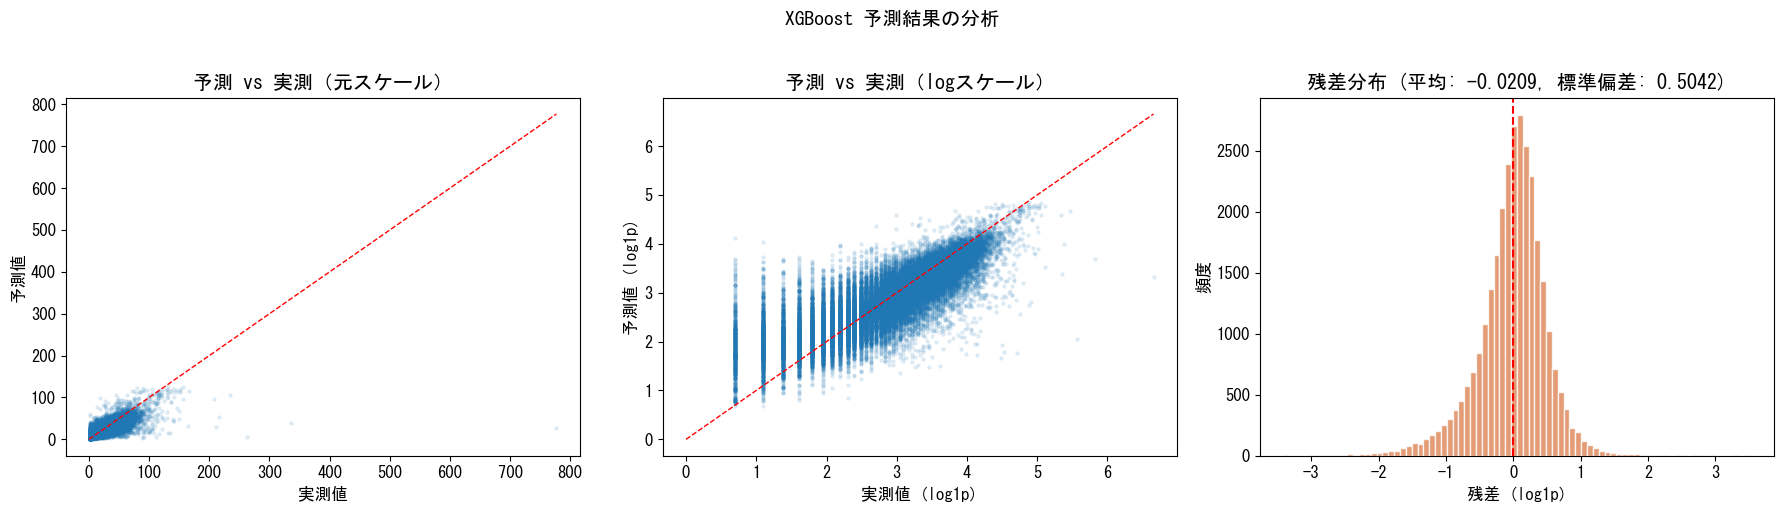

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 散布図（元スケール）
axes[0].scatter(valid_df['visitors'], pred, alpha=0.1, s=5)
max_val = max(valid_df['visitors'].max(), pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
axes[0].set_xlabel('実測値')
axes[0].set_ylabel('予測値')
axes[0].set_title('予測 vs 実測（元スケール）')

# 散布図（logスケール）
axes[1].scatter(np.log1p(valid_df['visitors']), pred_log, alpha=0.1, s=5)
max_log = max(np.log1p(valid_df['visitors']).max(), pred_log.max())
axes[1].plot([0, max_log], [0, max_log], 'r--', linewidth=1)
axes[1].set_xlabel('実測値 (log1p)')
axes[1].set_ylabel('予測値 (log1p)')
axes[1].set_title('予測 vs 実測（logスケール）')

# 残差分布
residuals = np.log1p(valid_df['visitors'].values) - pred_log
axes[2].hist(residuals, bins=80, color='#DD8452', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('残差 (log1p)')
axes[2].set_ylabel('頻度')
axes[2].set_title(f'残差分布 (平均: {residuals.mean():.4f}, 標準偏差: {residuals.std():.4f})')

plt.suptitle('XGBoost 予測結果の分析', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

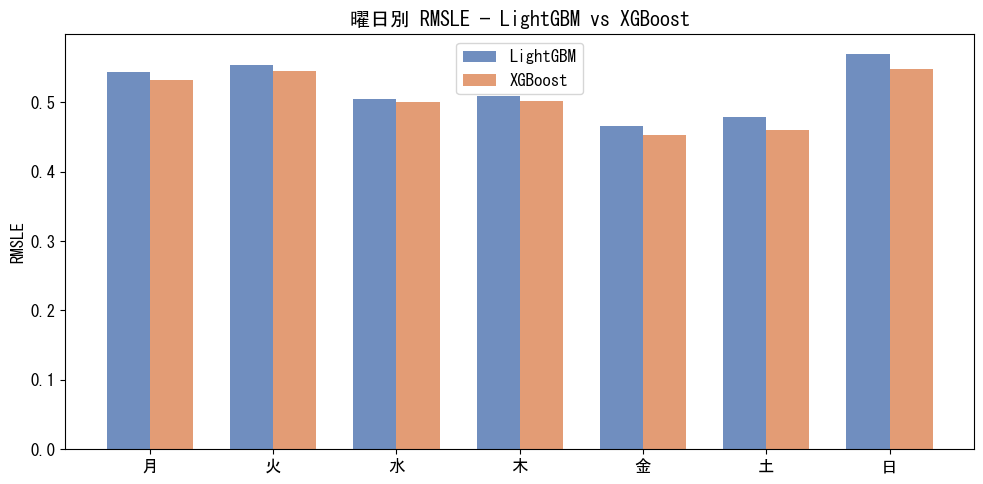

In [6]:
# セグメント別スコア
dow_names = ['月', '火', '水', '木', '金', '土', '日']
dow_scores_xgb = []
for d in range(7):
    mask = valid_df['dow'] == d
    s = rmsle(valid_df.loc[mask, 'visitors'], pred[mask.values])
    dow_scores_xgb.append(s)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(7)
width = 0.35
# LightGBMの曜日別スコアを再計算
lgbm_pred = prev_lgbm['valid_pred']
lgbm_actual = prev_lgbm['valid_actual']
dow_scores_lgbm = []
for d in range(7):
    mask = valid_df['dow'] == d
    s = rmsle(lgbm_actual[mask.values], lgbm_pred[mask.values])
    dow_scores_lgbm.append(s)

ax.bar(x - width/2, dow_scores_lgbm, width, label='LightGBM', color='#4C72B0', alpha=0.8)
ax.bar(x + width/2, dow_scores_xgb, width, label='XGBoost', color='#DD8452', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(dow_names)
ax.set_ylabel('RMSLE')
ax.set_title('曜日別 RMSLE — LightGBM vs XGBoost')
ax.legend()

plt.tight_layout()
plt.show()

---
## 6. 特徴量重要度の分析

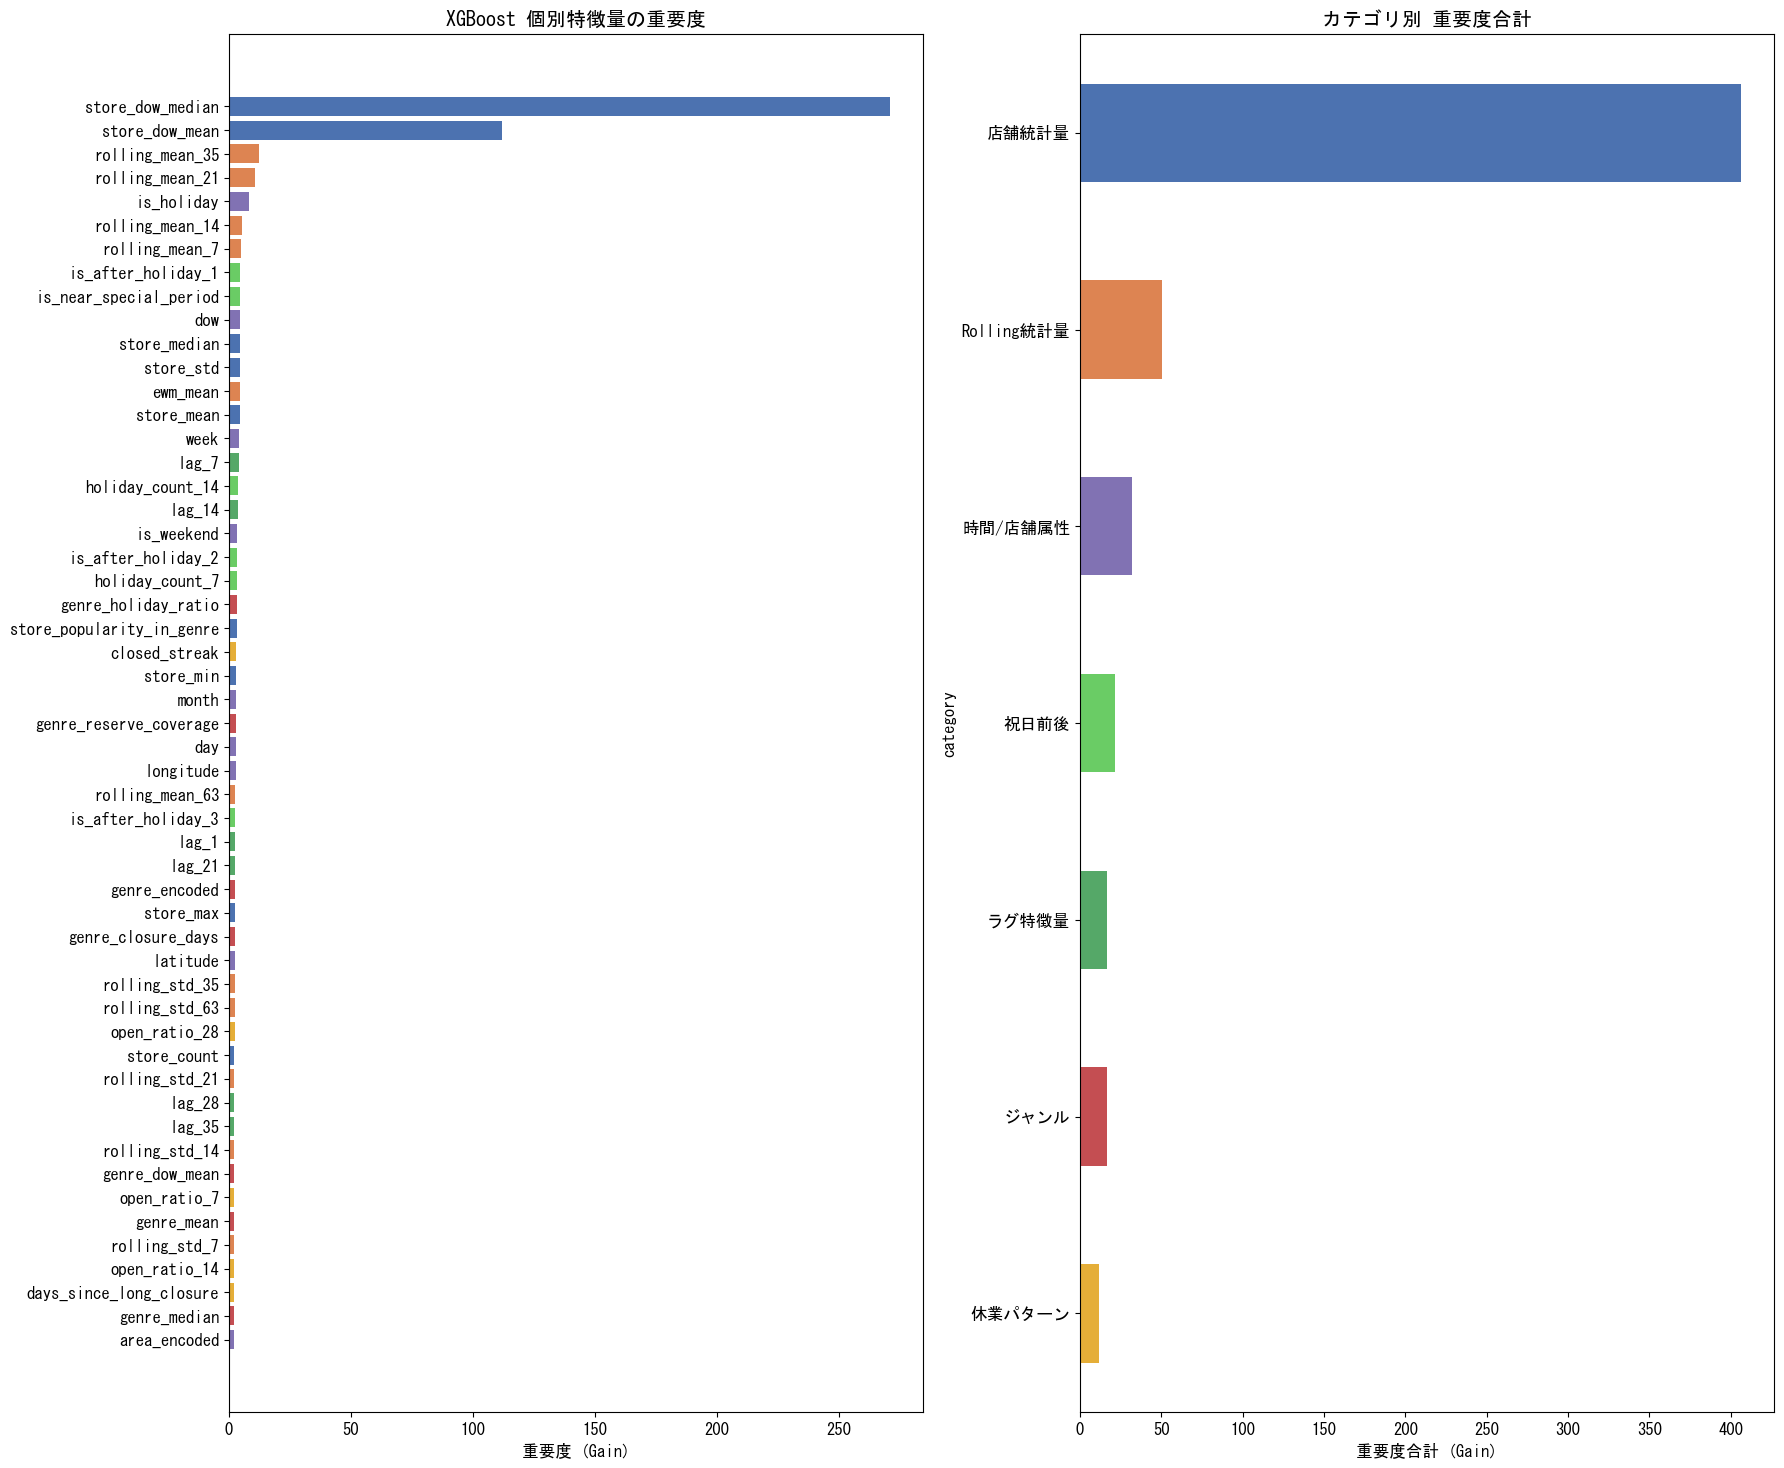


=== 上位10特徴量 ===
  [店舗統計量   ] store_dow_median: 271
  [店舗統計量   ] store_dow_mean: 112
  [Rolling統計量] rolling_mean_35: 12
  [Rolling統計量] rolling_mean_21: 11
  [時間/店舗属性 ] is_holiday: 8
  [Rolling統計量] rolling_mean_14: 5
  [Rolling統計量] rolling_mean_7: 5
  [祝日前後    ] is_after_holiday_1: 5
  [祝日前後    ] is_near_special_period: 5
  [時間/店舗属性 ] dow: 5


In [7]:
# XGBoostの特徴量重要度（Gain）
raw_importance = model.get_score(importance_type='gain')
importance = pd.DataFrame({
    'feature': all_features,
    'importance': [raw_importance.get(f, 0) for f in all_features]
}).sort_values('importance', ascending=True)

def categorize_feature(name):
    if name.startswith('rolling_') or name.startswith('ewm_'):
        return 'Rolling統計量'
    elif name.startswith('lag_'):
        return 'ラグ特徴量'
    elif name.startswith(('open_ratio_', 'closed_streak', 'days_since_')):
        return '休業パターン'
    elif name.startswith(('is_after_holiday_', 'holiday_count_', 'is_near_special')):
        return '祝日前後'
    elif name.startswith('store_'):
        return '店舗統計量'
    elif name.startswith('genre_'):
        return 'ジャンル'
    else:
        return '時間/店舗属性'

importance['category'] = importance['feature'].apply(categorize_feature)

color_map = {
    'Rolling統計量': '#DD8452', 'ラグ特徴量': '#55A868',
    '店舗統計量': '#4C72B0', 'ジャンル': '#C44E52', '時間/店舗属性': '#8172B3',
    '休業パターン': '#E5AE38', '祝日前後': '#6ACC65'
}

fig, axes = plt.subplots(1, 2, figsize=(18, max(10, len(all_features) * 0.28)))

colors = importance['category'].map(color_map)
axes[0].barh(importance['feature'], importance['importance'], color=colors)
axes[0].set_xlabel('重要度 (Gain)')
axes[0].set_title('XGBoost 個別特徴量の重要度')

cat_imp = importance.groupby('category')['importance'].sum().sort_values()
cat_colors = [color_map.get(c, 'gray') for c in cat_imp.index]
cat_imp.plot(kind='barh', ax=axes[1], color=cat_colors)
axes[1].set_xlabel('重要度合計 (Gain)')
axes[1].set_title('カテゴリ別 重要度合計')

plt.tight_layout()
plt.show()

print('\n=== 上位10特徴量 ===')
for _, row in importance.tail(10).iloc[::-1].iterrows():
    print(f'  [{row["category"]:8s}] {row["feature"]}: {row["importance"]:.0f}')

---
## 7. LightGBMとの比較

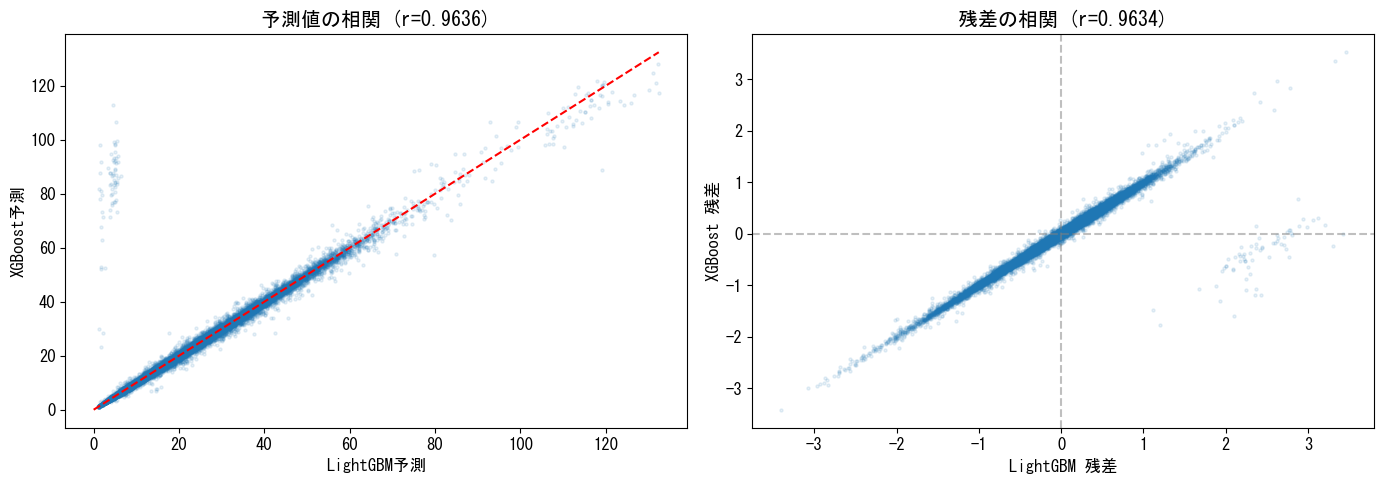

予測値の相関: 0.9636
残差の相関: 0.9634

→ 残差の相関が1.0未満であれば、アンサンブルで改善の余地がある


In [8]:
# 予測値の相関
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(prev_lgbm['valid_pred'], pred, alpha=0.1, s=5)
max_val = max(prev_lgbm['valid_pred'].max(), pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--')
axes[0].set_xlabel('LightGBM予測')
axes[0].set_ylabel('XGBoost予測')
corr = np.corrcoef(prev_lgbm['valid_pred'], pred)[0, 1]
axes[0].set_title(f'予測値の相関 (r={corr:.4f})')

# 残差の差分
lgbm_residuals = prev_lgbm['residuals']
xgb_residuals = residuals
axes[1].scatter(lgbm_residuals, xgb_residuals, alpha=0.1, s=5)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('LightGBM 残差')
axes[1].set_ylabel('XGBoost 残差')
resid_corr = np.corrcoef(lgbm_residuals, xgb_residuals)[0, 1]
axes[1].set_title(f'残差の相関 (r={resid_corr:.4f})')

plt.tight_layout()
plt.show()

print(f'予測値の相関: {corr:.4f}')
print(f'残差の相関: {resid_corr:.4f}')
print(f'\n→ 残差の相関が1.0未満であれば、アンサンブルで改善の余地がある')

---
## 8. ハイパーパラメータチューニング（Optuna）

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50

def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'booster': 'gbtree',
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': SEED,
        'n_jobs': -1,
        'verbosity': 0,
    }

    # val_foldsベースのCV平均で最適化（Single Split過適合を防止）
    fold_scores = []
    for fold in val_folds:
        val_start = pd.Timestamp(fold['val_start'])
        val_end = pd.Timestamp(fold['val_end'])

        train_mask = full_df['visit_date'] < val_start
        valid_mask = (full_df['visit_date'] >= val_start) & (full_df['visit_date'] <= val_end)

        fold_train = full_df[train_mask]
        fold_valid = full_df[valid_mask]

        if len(fold_train) == 0 or len(fold_valid) == 0:
            continue

        dtr = xgb.DMatrix(fold_train[all_features], label=np.log1p(fold_train['visitors']))
        dva = xgb.DMatrix(fold_valid[all_features], label=np.log1p(fold_valid['visitors']))

        m = xgb.train(
            params, dtr, num_boost_round=2000,
            evals=[(dva, 'valid')],
            early_stopping_rounds=50, verbose_eval=0,
        )

        p = np.expm1(m.predict(dva))
        fold_scores.append(rmsle(fold_valid['visitors'], p))

    return np.mean(fold_scores) if fold_scores else float('inf')

# Optuna チューニング
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'=== Optunaチューニング結果 ({N_TRIALS}試行, {len(val_folds)}フォールドCV) ===')
print(f'  デフォルト CV平均 RMSLE: {np.mean(cv_scores):.5f}')
print(f'  最適化後 CV平均 RMSLE:  {study.best_value:.5f}')
print(f'  改善幅: {np.mean(cv_scores) - study.best_value:+.5f}')
print(f'\n最適パラメータ:')
for k, v in study.best_params.items():
    print(f'  {k}: {v:.6f}' if isinstance(v, float) else f'  {k}: {v}')

# --- ベストパラメータで再学習（Single Split） ---
tuned_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'booster': 'gbtree',
    'random_state': SEED,
    'n_jobs': -1,
    'verbosity': 0,
}
tuned_params.update(study.best_params)

tuned_model = xgb.train(
    tuned_params, dtrain,
    num_boost_round=2000,
    evals=[(dtrain, 'train'), (dvalid, 'valid')],
    early_stopping_rounds=100,
    verbose_eval=200,
)

tuned_pred_log = tuned_model.predict(dvalid)
tuned_pred = np.expm1(tuned_pred_log)
tuned_score = rmsle(valid_df['visitors'], tuned_pred)

print(f'\n=== チューニング前後の比較 ===')
print(f'{"モデル":<20s} {"RMSLE":>10s} {"Best Iter":>10s}')
print(f'{"XGBoost (手動)":<20s} {score_single:>10.5f} {model.best_iteration:>10d}')
print(f'{"XGBoost (Optuna)":<20s} {tuned_score:>10.5f} {tuned_model.best_iteration:>10d}')
print(f'{"LightGBM":<20s} {prev_lgbm["score_single"]:>10.5f} {"":>10s}')
print(f'\n改善幅: {score_single - tuned_score:+.5f}')

---
## 9. まとめと次ステップ

In [ ]:
print('=== モデル比較 ===')
print(f'{"モデル":<25s} {"Single RMSLE":>14s} {"CV平均 RMSLE":>14s}')
print(f'{"ルールベース(store×DOW)":<25s} {baseline_rmsle:>14.5f} {"—":>14s}')
print(f'{"LightGBM":<25s} {prev_lgbm["score_single"]:>14.5f} {prev_lgbm["cv_mean"]:>14.5f}')
print(f'{"XGBoost":<25s} {score_single:>14.5f} {np.mean(cv_scores):>14.5f}')
print(f'{"XGBoost (Optuna)":<25s} {tuned_score:>14.5f} {study.best_value:>14.5f}')
print(f'\n予測値の相関: {corr:.4f}')
print(f'残差の相関: {resid_corr:.4f}')
print(f'\n→ ベースラインからの改善幅: {baseline_rmsle - tuned_score:.5f}')
print(f'→ 次のステップ（03-3）でRandomForestモデルを構築する。')

In [ ]:
# 中間データの保存
results_03_2 = {
    'valid_pred': pred,
    'valid_pred_log': pred_log,
    'valid_actual': valid_df['visitors'].values,
    'score_single': score_single,
    'cv_scores': cv_scores,
    'cv_mean': np.mean(cv_scores),
    'cv_std': np.std(cv_scores),
    'feature_importance': importance,
    'params': xgb_params,
    'best_iteration': model.best_iteration,
    'residuals': residuals,
    'pred_corr_with_lgbm': corr,
    'resid_corr_with_lgbm': resid_corr,
    # ルールベースベースライン
    'baseline_rmsle': baseline_rmsle,
    'baseline_pred': baseline_pred.values,
    'store_dow_median': store_dow_median,
    # Optuna チューニング結果
    'tuned_pred': tuned_pred,
    'tuned_pred_log': tuned_pred_log,
    'tuned_score': tuned_score,
    'tuned_params': tuned_params,
    'tuned_best_iteration': tuned_model.best_iteration,
    'optuna_best_params': study.best_params,
}

with open(INTERMEDIATE_DIR / '03-2_xgb_results.pkl', 'wb') as f:
    pickle.dump(results_03_2, f)

tuned_model.save_model(str(INTERMEDIATE_DIR / '03-2_xgb_model.json'))

print('中間データ保存完了:')
print(f'  結果: {INTERMEDIATE_DIR / "03-2_xgb_results.pkl"}')
print(f'  モデル (Optunaチューニング済): {INTERMEDIATE_DIR / "03-2_xgb_model.json"}')